# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 22 - 5to bimestre 2025

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23hs del viernes 28 de noviembre (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/kvD11QBVSHbHA8QDA)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co22.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es mejor o igual a 50K o mayor a 50K.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
import sklearn
torch.manual_seed(42) # Reproducibilidad

# Topeo la cantidad de threads que torch puede usar a 10 para que mi máquina sea usable mientras entrena
# Intra-op parallelism (the heavy lifter for matrix mult)
torch.set_num_threads(10) 
# Inter-op parallelism (usually fine at default, but can be lowered)
torch.set_num_interop_threads(10)

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [4]:
df = pd.read_csv('adult_train.csv')
df.describe()

,age,capital-gain,capital-loss,hours-per-week
count,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1092.007858,88.372489,40.931238
std,13.134665,7406.346497,404.298370,11.979984
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


A continuación tenemos histogramas para todas las variables. En primer lugar se tienen los histogramas directos, y en segundo lugar normalizados de forma de poder ver la proporción de ingresos dentro de cada subcategoría.

En cuanto a la distrbución de las variables categóricas podemos notar:
- `workclass`: la mayoría trabaja en el sector privado. Se tiene una cantidad casi nula de personas sin paga. Los de mayor proporción de altos ingresos son los `self-emp-inc`. Los `without-pay` tienen bajos ingresos (esperablemente).
- `education`: la mayoría es graduada de high-school, luego se tiene some-college y bachelor. El resto tiene frecuencia bastante menor y bastante uniforme entre sí. Muchos de los grados indicados serían menores a High-School, agruparlos sería razonable. Los graduados de `Doctorate`, `Prof-school`, `Masters` y `Bachelors` son los que mayor proporción de ingreso alto tienen.   
- `marital-status`: se tiene una primer mayoría casada, seguida por los individuos que nunca se casaron, y luego los divorciados. El resto de categorías se encuentran menos representadas. Ambas categorías de casados tienen una proporción alta de altos ingresos. El resto tienen mayoritariamente ingresos bajos.
- `ocupation`: se observan 2 grupos con mayor y menor frecuencia respectivamente. Además `armed-forces` y `priv-house-serv` se encuentran aún menos representadas que el 2do grupo.
- `relationship`: la mayoría es esposo, con en segundo lugar sin familia. Luego se tienen frecuencias decrecientes. Los esposos y esposas son los que mayor proporción de ingresos altos tienen (en linea con que en `marital-status` los casados tenían proporción alta de ingresos altos).
- `race`: la raza preponderante es blanco, y el resto están representados en medidas bastante menores.
- `sex`: la mayoría son hombres. Esto tiene sentido teniendo en cuenta que en `relationship` se tiene esposo con la mayor frecuencia y esposa con la menor frecuencia, y que casado es el `martial-status` más frecuente. Los hombres tienen una mayor proporción de individuos con ingresos altos.
- `native-country`: Estados Unidos es el país más representado con diferencia. El resto de países están representados en mucho menor medida. Se observa que algunos países tienen una proporción simil a EEUU e incluso mayor, mientras que algunos tienen proporciones claramente menores. Se pueden observar 2 posibles niveles de países a groso modo, uno con mayor y otro con menor proporción de individuos de ingresos altos.

Si analizamos las métricas básicas de las variables numéricas, podemos ver que:
- `age`: la media de edad es 38 años, con el cuantil 75 estando a los 47 años. Se tiene que la proporción de personas con ingresos >= 50k aumenta hasta un máximo en 50-55 años, y luego empieza a decrecer, con algunos picos particulares (probablemente pocos datos para edades tan altas).
- `capital-loss`y `capital-gain`: tanto las ganancias como pérdidas de cpaital presentan un cuantil 75 de 0, es decir que al menos el 75% de los individuos no tuvieron ni ganancia ni pérdida de capital. Además el tope de ganancia de capital es de 99999, lo cual parecería indicar que se tenía un valor máximo admitido a la hora de tomar estos datos. Además en el histograma se ve una alta concentración en estos valores (*nota: el histograma no tiene graficados los valores 0 ya que es un valor demasiado repetido y no se logra percibir como están representados los valores >0*). Esto último podría indicarnos que sería más representativo discretizar esta variable en una categórica ordinal, teniendo >99999 como ganancia de capital alta.
- `hours-per-week`: en las horas trabajadas por semana se ve que, esperablemente, la media está en 40 horas por semana, y además viendo el histograma vemos que se tiene una alta densidad en ese valor de horas trabajadas.

Consideremos ahora la información aportada por la diferenciación entre el ingreso:
- En la edad vemos una distribución más centrada en 35-45 años para el ingreso mayor, teniendo una distrbución más asimétrica izquierda para ingresos menores.
- En la educación se observa que Bachelors, Masters, Prof-school y Doctorate tienen mayor proporción de ingresos mayores que el resto de categorías.
- En el estado marital, se ve que los casados tienen una proporción mucho mayor de ingresos mayores.
- En la ocupación, se tiene mayor proporción de ingresos mayores para los `Exec-managerial` y `Prof-speciality`.
- En la relación, los epsposos y las esposas tienen mayor proporción de ingresos mayores que el resto de relaciones.
- En la ganancia de capital se ve una tendencia a tener mayores ingresos a mayores ganancias de capital. *Nota: también se ve una proporción mayor de mayores ingresos a ganancias de capital nula*



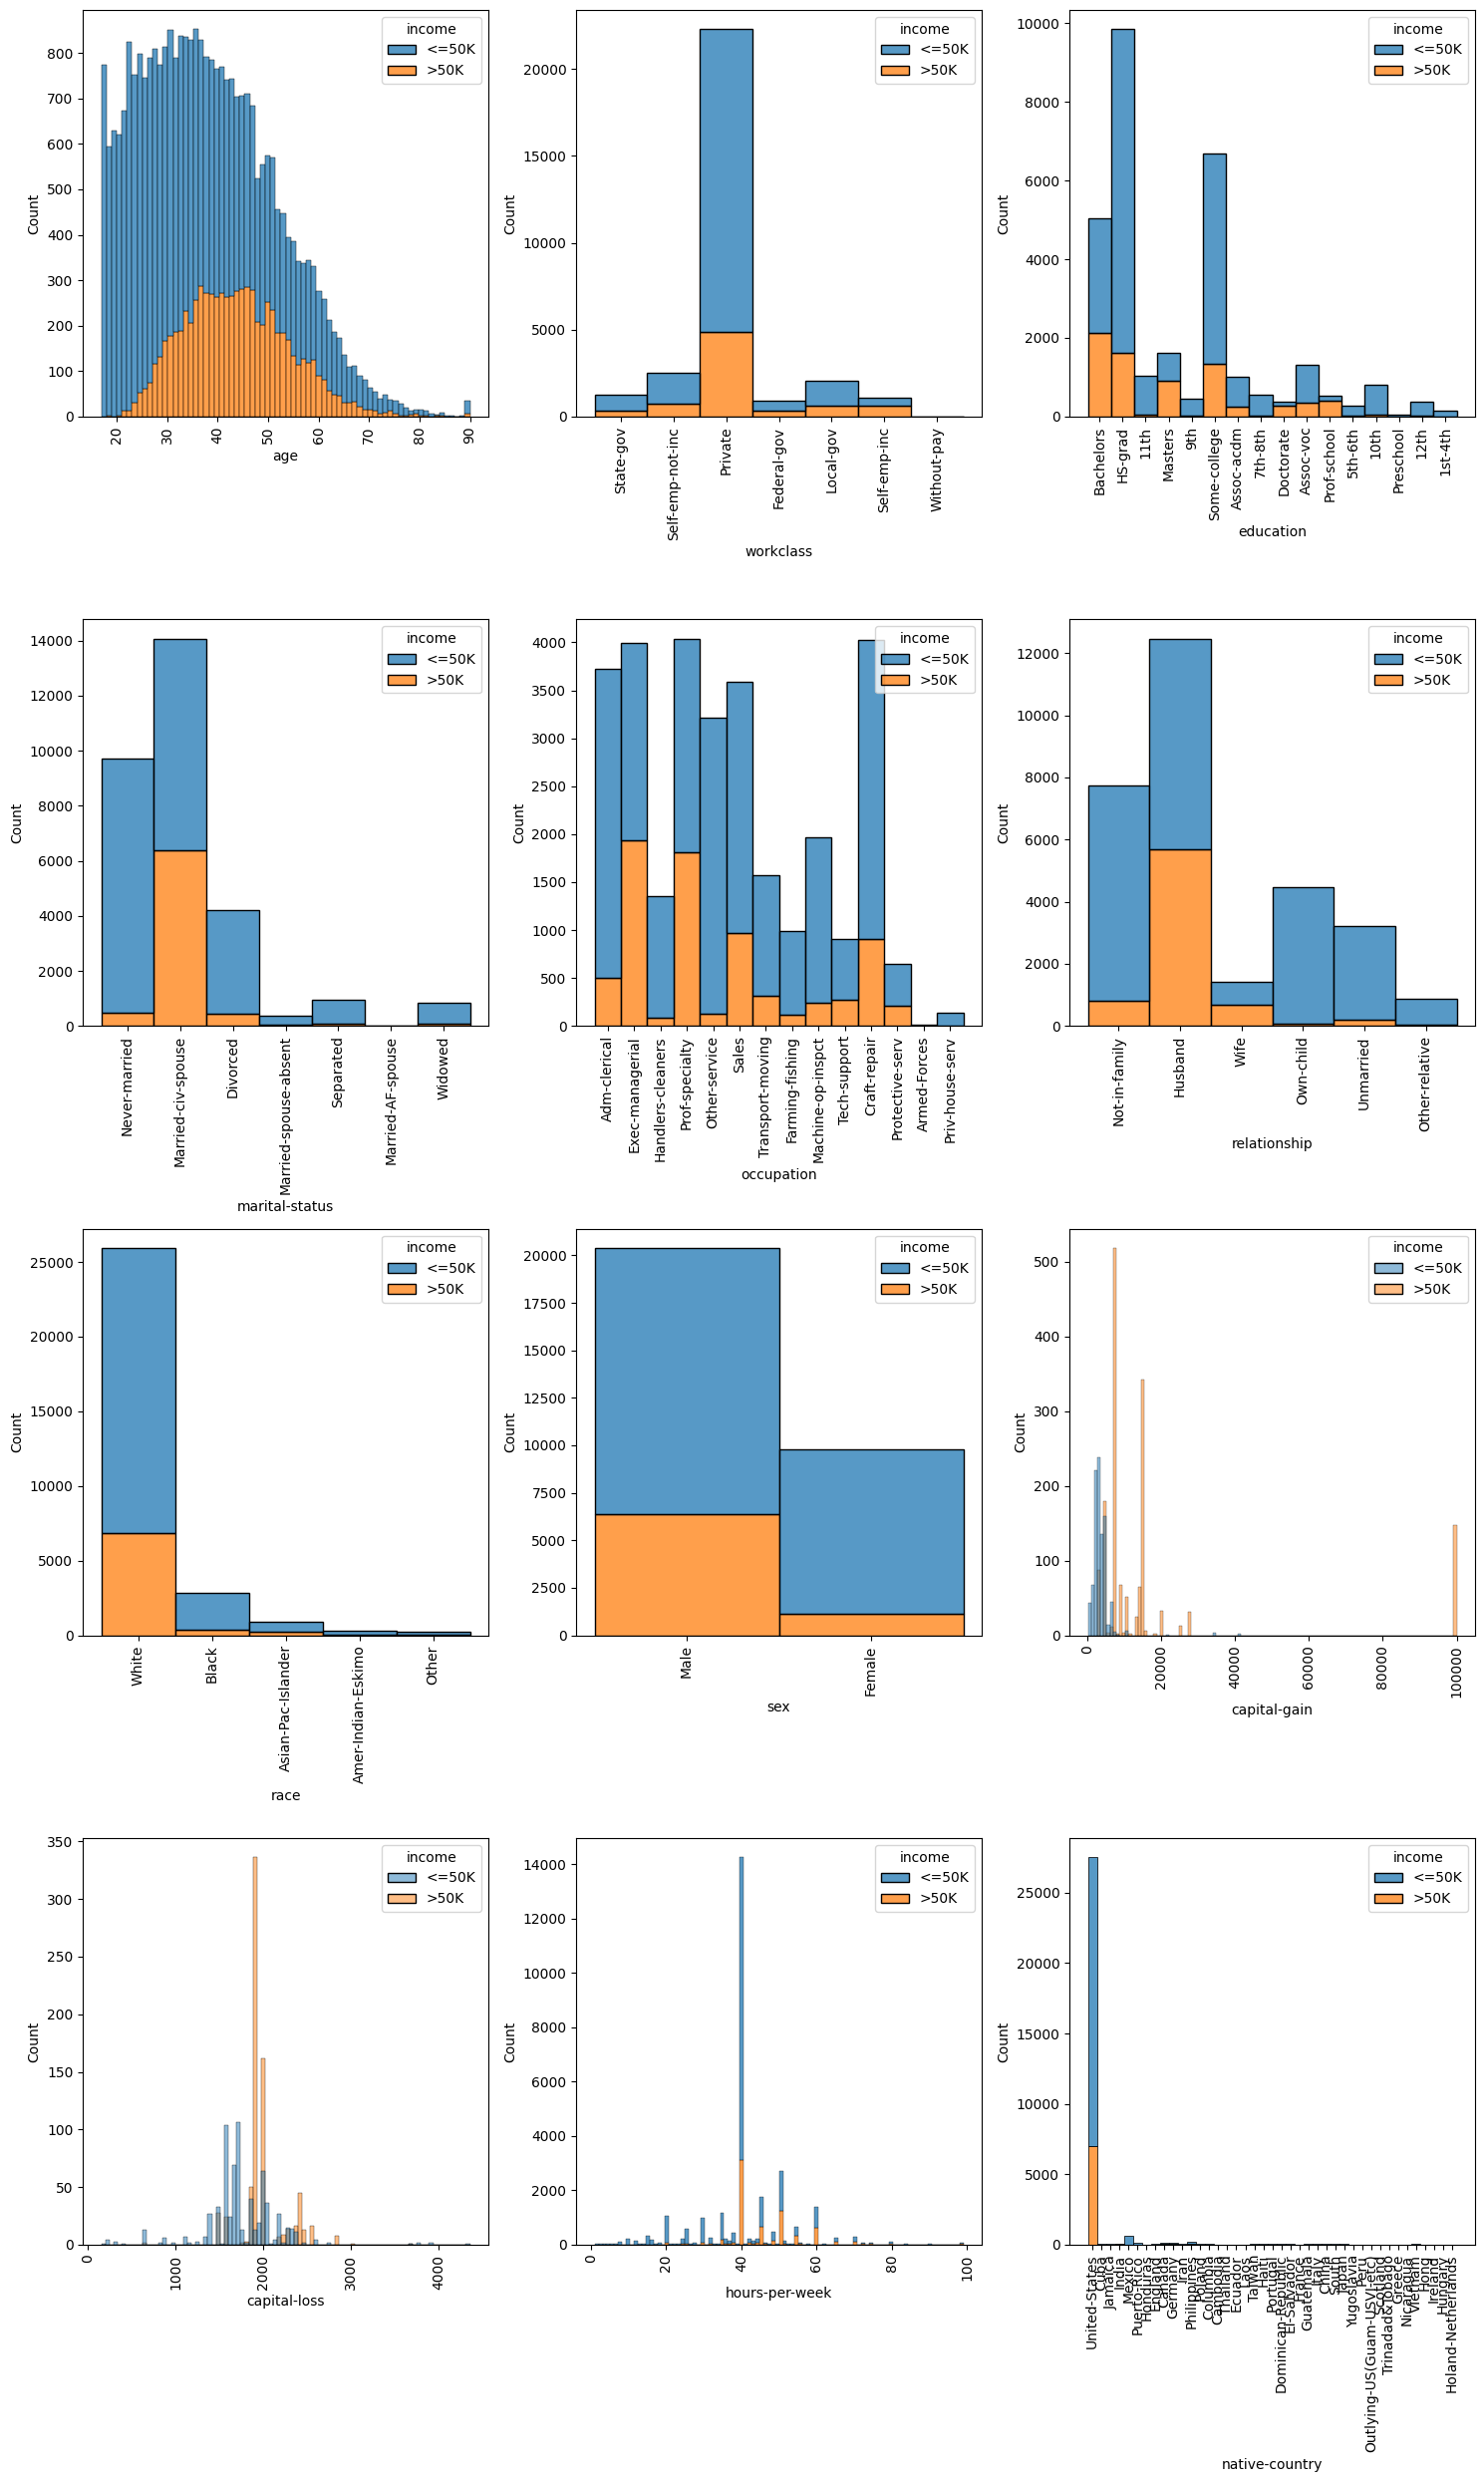

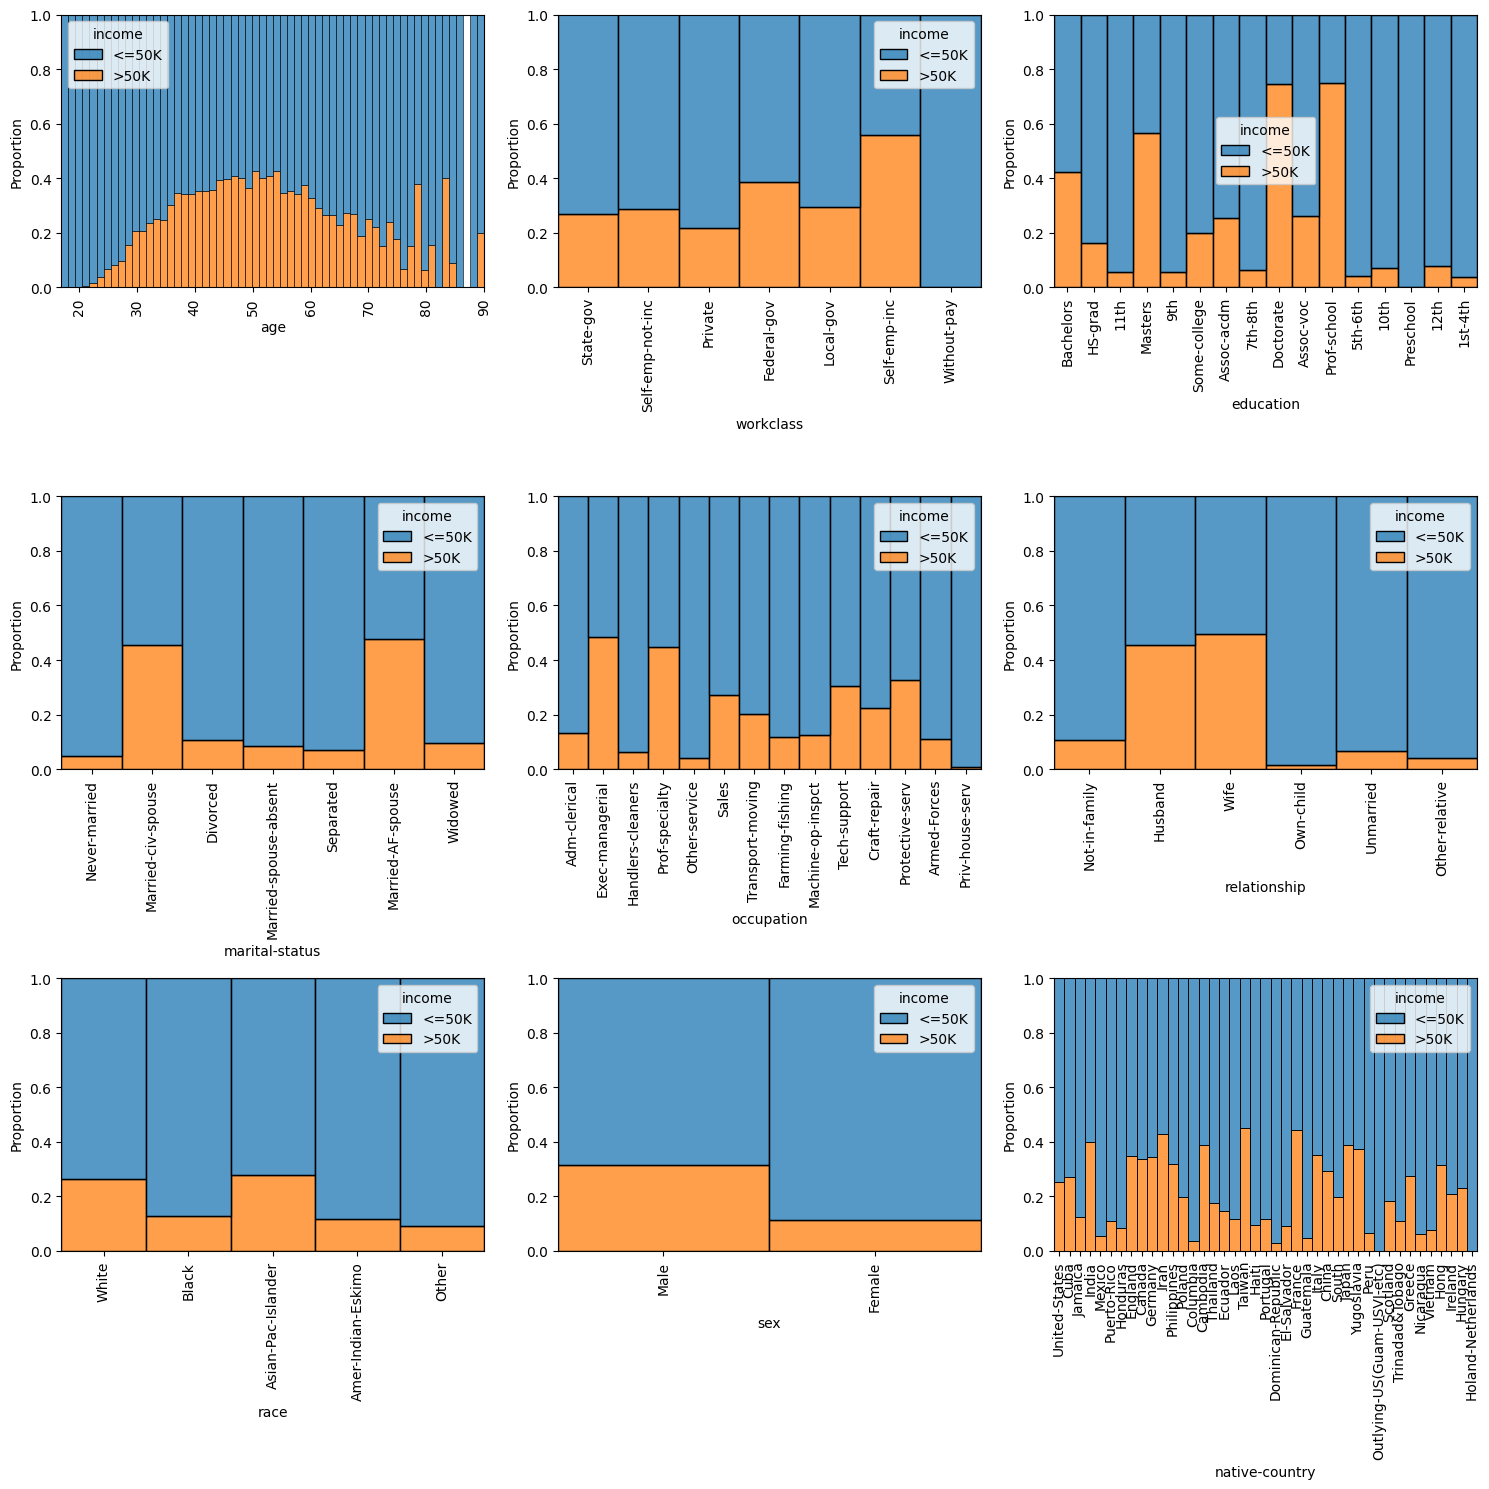

workclass: 7 valores únicos
education: 16 valores únicos
marital-status: 7 valores únicos
occupation: 14 valores únicos
relationship: 6 valores únicos
race: 5 valores únicos
sex: 2 valores únicos
native-country: 41 valores únicos


In [5]:
fig, axs = plt.subplots(4,3,figsize=(15,25))
for idx, col in enumerate(['age','workclass','education','marital-status','occupation','relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country']):
    if col in ['age', 'hours-per-week']:
        sns.histplot(data=df, x=col, ax=axs[idx//3][idx%3], bins=len(df[col].value_counts()), hue='income', multiple='stack')
    elif col in ['capital-gain', 'capital-loss']:
        sns.histplot(data=df[ df[col]!= 0], x=col, ax=axs[idx//3][idx%3], bins=len(df[col].value_counts()), hue='income')
        # sns.histplot(data=df, x=col, ax=axs[idx//3][idx%3], bins=len(df[col].value_counts()), hue='income', multiple='stack')
        # axs[idx//3][idx%3].set_yscale('log')
    else:
        # sns.countplot(data=df, x=col, ax=axs[idx//3][idx%3], hue='income')
        sns.histplot(data=df, x=col, ax=axs[idx//3][idx%3], hue='income', multiple='stack')
    axs[idx//3][idx%3].tick_params(axis='x', rotation=90)
plt.tight_layout() 
plt.show()

fig, axs = plt.subplots(3,3,figsize=(15,15))
for idx, col in enumerate(['age','workclass','education','marital-status','occupation','relationship','race','sex','native-country']):
    value_counts = df.groupby('income')[col].value_counts(normalize=True).rename('Percentage').reset_index()
    sns.histplot(data=df, x=col, ax=axs[idx//3][idx%3], hue='income', multiple='fill', stat='proportion')

    axs[idx//3][idx%3].tick_params(axis='x', rotation=90)

plt.tight_layout() 
plt.show()


for idx, col in enumerate(['workclass','education','marital-status','occupation','relationship','race','sex','native-country']):
    print(f"{col}: {len(df[col].value_counts())} valores únicos")

In [6]:
df['native-country'].value_counts()

native-country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
El-Salvador                     100
India                           100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Columbia                         56
Poland                           56
Haiti                            42
Iran                             42
Taiwan                           42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                           29
France       

In [7]:
df_val = pd.read_csv('adult_val.csv')
df_val.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [88]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler

# Agrupemos las educaciones menores a High-School en No-Diploma y los 2 tipos de Assoc en 1
def group_eds(ed):
    '''
    group_eds: agrupa educaciones que son demasiado especificas
    '''
    if ed == 'Assoc-voc' or ed == 'Assoc-acdm':
        return 'Associate'
    elif ed in ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']:
        return 'No-Diploma'
    else:
        return ed
df['education'] = df['education'].map(group_eds)

def scale_df(df, scalers_to_use, ordinal_encoder_cats={}):
    '''
    scale_df: escala un pandas.DataFrame según los escaladores especificados. No escala la label age.
    args:
    - df: DataFrame a escalar
    - saclers_to_use: Scalers a utilizar. Opciones: one_hot_binary, one_hot, ordinal, label, standard
    - ordinal_encoder_cars: categorías a pasar a los ordinal encorders
    '''
    df_encoded = df[['age']].copy()
    scalers = {}
    len_labels = {}

    for col in scalers_to_use.keys():
        scl = scalers_to_use[col]
        if scl == 'one_hot_binary':
            encoder = OneHotEncoder(drop='if_binary')
            df_encoded[col] = encoder.fit_transform(df[col].array.reshape(-1,1)).toarray()
        elif scl == 'one_hot':
            encoder = OneHotEncoder()
            df_encoded[df[col].unique()] = encoder.fit_transform(df[col].array.reshape(-1,1)).toarray()
        elif scl == 'ordinal':
            encoder = OrdinalEncoder(categories=[ordinal_encoder_cats[col]])
            df_encoded[col] = encoder.fit_transform(df[col].array.reshape(-1,1))
        elif scl == 'label':
            encoder = LabelEncoder()
            df_encoded[col] = encoder.fit_transform(df[col].array.ravel())
            len_labels[col] = len(df_encoded[col].unique())
        elif scl == 'standard':
            encoder = StandardScaler()
            df_encoded[col] = encoder.fit_transform(df[col].array.reshape(-1,1))
        scalers[col] = encoder
    
    return df_encoded, scalers, len_labels

def scale_test_df(df_test, df_train, scalers):
    df_test_encoded = df_test[['age']].copy()
    for col in scalers.keys():
        print(f"{col} -> {scalers[col]}")
        if isinstance(scalers[col], (StandardScaler, OrdinalEncoder)):
            df_test_encoded[col] = scalers[col].transform(df_test[col].array.reshape(-1,1))
        elif isinstance(scalers[col], OneHotEncoder):
            if scalers[col].get_params().get('drop') == 'if_binary':
                df_test_encoded[col] = scalers[col].transform(df_test[col].array.reshape(-1,1)).toarray()
            else:
                df_test_encoded[df_train[col].unique()] = scalers[col].transform(df_test[col].array.reshape(-1,1)).toarray()
        elif isinstance(scalers[col], LabelEncoder):
            df_test_encoded[col] = scalers[col].transform(df_test[col].array.ravel())
    return df_test_encoded


scalers_to_use = {
    'sex': 'one_hot_binary',
    'capital-gain': 'standard',
    'capital-loss': 'standard',
    'hours-per-week': 'standard',
    'education': 'ordinal',
    'workclass': 'one_hot',
    'marital-status': 'one_hot',
    'relationship': 'one_hot',
    'race': 'one_hot',
    'occupation': 'label',
    'native-country': 'label',
    'income': 'ordinal'
}
ordinal_encoder_cats = {
    'education': ['No-Diploma', 'HS-grad', 'Some-college', 'Associate', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate'],
    'income': ['<=50K', '>50K'] 
}
df_encoded, scalers, len_labels = scale_df(df, scalers_to_use, ordinal_encoder_cats)
len_occupations = len_labels['occupation']
len_countries = len_labels['native-country']
df_encoded

,age,sex,capital-gain,capital-loss,hours-per-week,education,State-gov,Self-emp-not-inc,Private,Federal-gov,...,Unmarried,Other-relative,White,Black,Asian-Pac-Islander,Amer-Indian-Eskimo,Other,occupation,native-country,income
0,39,1.0,0.146092,-0.218586,-0.077734,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,38,0.0
1,50,1.0,-0.147445,-0.218586,-2.331531,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3,38,0.0
2,38,1.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5,38,0.0
3,53,1.0,-0.147445,-0.218586,-0.077734,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5,38,0.0
4,28,0.0,-0.147445,-0.218586,-0.077734,4.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,9,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,0.0,-0.147445,-0.218586,-0.244682,3.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,12,38,0.0
30158,40,1.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6,38,1.0
30159,58,0.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,38,0.0
30160,22,1.0,-0.147445,-0.218586,-1.747213,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,38,0.0


## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación.

In [ ]:
from torch.utils.data import DataLoader, Dataset
from torch import nn
from collections import OrderedDict

class IncomeDataset(Dataset):
    def __init__(self, data, device):
        self.x = torch.tensor(data.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long).to(device)
        self.occupation = torch.tensor(data['occupation'].values, dtype=torch.long).to(device)
        self.country = torch.tensor(data['native-country'].values, dtype=torch.long).to(device)
        self.income = torch.tensor(data['income'].values, dtype=torch.float32).to(device)
    def __len__(self):
        return self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.occupation[index], self.country[index], self.income[index]

class NNetModel(nn.Module):
    def __init__(self, occupations, countries, x_shape, n_per_layer=128, layers=4, emb_dim=64, p=0.1):
        super().__init__()
        # definir los embeddings de occupation y countries
        self.ocuppation_embeddings = nn.Embedding(occupations, emb_dim)
        nn.init.normal_(self.ocuppation_embeddings.weight, std=0.1)
        self.countries_embeddings = nn.Embedding(countries, emb_dim)
        nn.init.normal_(self.countries_embeddings.weight, std=0.1)

        # definamos la red
        # capa de input
        network_order = [
            ('input_drop', nn.Dropout(p)),
            ('input', nn.Linear(emb_dim * 2 + x_shape - 3, n_per_layer)),
            ('input_act', nn.LeakyReLU())
        ]
        # capas ocultas
        for i in range(layers):
            network_order.append((f'drop_{i}', nn.Dropout(p)))
            network_order.append((f'layer_{i}', nn.Linear(n_per_layer, n_per_layer)))
            network_order.append((f'act_{i}', nn.LeakyReLU()))
        # capas de output
        network_order.append((f'drop_out', nn.Dropout(p)))
        network_order.append((f'output', nn.Linear(n_per_layer, 1)))
        network_order.append((f'out_act', nn.Sigmoid()))
        # instanciemos la red
        self.network = nn.Sequential(
            OrderedDict(network_order) 
        ).to(device)
    
    def forward(self, x, occupation_values, countries_values):
        oc_values = self.ocuppation_embeddings(occupation_values)
        cou_values = self.countries_embeddings(countries_values)
        x = torch.cat([x, oc_values, cou_values], dim=1)
        y = self.network(x)
        return y.squeeze(1)

def train_model(model, dataloader, optimizer, criteria, epochs=100, log=True):
    loss_evol = []

    for epoch in range(epochs):
        model.train()
        train_mse = []
        for xi, oc_i, count_i, yi in dataloader:
            yhat = model(xi, oc_i, count_i)
            loss = criteria(yhat, yi)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            train_mse.append(loss.item())
        loss_evol.append(np.mean(train_mse))
        if log:
            print(f'Epoch {epoch+1}: loss={np.mean(train_mse)}')
    
    return loss_evol

In [52]:
def get_best_thresholds(yhat, y_true, log=True):
    '''
    get_best_thresholds: get the best thresholds for a classification model based on the J approach (farthest point from the random guess line) and the geometric distance approach (nearest point to the perfect model)
    args:
    - yhat: prediction
    - y_true: true values
    returns:
    - best_thr_J: best threshold according to the J approach
    - best_thr_geom_dist: best threshold according to the geometric distance approach
    '''
    fpr, tpr, thr = sklearn.metrics.roc_curve(y_true=y_true, y_score=yhat)

    J = tpr - fpr
    idx = np.argmax(J)
    best_thr_J = thr[idx]

    geom_dist = np.sqrt((1-tpr)**2 + fpr**2)
    idx_2 = np.argmin(geom_dist)
    best_thr_geom_dist = thr[idx_2]

    if log:
        print(f"Farthest from random guess -> Best threshold = {best_thr_J}")
        print(f"Nearest perfect model -> Best threshold = {best_thr_geom_dist}")

    return best_thr_J, best_thr_geom_dist

def apply_threshold(thr, yhat):
    '''
    apply_threshold: apply the specified threshold to a probability prediction.
    args:
    - thr
    - yhat
    returns:
    - yhat_thr
    '''
    yhat_thr = []
    for i in range(yhat.shape[0]):
        if yhat[i]>=thr:
            yhat_thr.append(1)
        else:
            yhat_thr.append(0)
    return yhat_thr

def plot_thr_confusion_matrixes(cm_J, cm_gd, title, fmt='.3f'):
    '''
    plots the given confusion matrixes for the J and geometric distance approach for best threshold of classification
    args:
    - cm_J
    - cm_gd
    - title
    '''
    fig, axs = plt.subplots(1,2, figsize=(10,4))
    fig.suptitle(title)
    sns.heatmap(cm_J, annot=True, ax=axs[0], fmt=fmt)
    axs[0].set_title('Furthest from guessing')
    sns.heatmap(cm_gd, annot=True, ax=axs[1], fmt=fmt)
    axs[1].set_title('Nearest to perfect model')
    for i in range(2):
        axs[i].set_ylabel('True label')
        axs[i].set_xlabel('Predicted label')
    plt.show()

def plot_confusion_matrix(cm, cm_norm, title):
    '''
    plots the given confusion matrix (the absolute and the normalized)
    args:
    - cm
    - title
    '''
    fig, axs = plt.subplots(1,2, figsize=(10,4))
    fig.suptitle(title)
    sns.heatmap(cm, annot=True, ax=axs[0], fmt='d')
    axs[0].set_title('Abosulte CM')
    sns.heatmap(cm_norm, annot=True, ax=axs[1], fmt='.3f')
    axs[1].set_title('Normalized CM')
    for i in range(2):
        axs[i].set_ylabel('True label')
        axs[i].set_xlabel('Predicted label')
    plt.show()

def print_metrics(cm, model_name='', no_print=False):
    '''
    prints the main metrics from a confussion matrix and return a dict with them
    '''
    metrics = {}
    # Sensitivity
    sensitivity = cm[1,1] / sum(cm[1,:])
    metrics['sensitivity'] = sensitivity
    # Specificity
    specificity = cm[0,0] / sum(cm[0,:])
    metrics['specificity'] = specificity
    # Accuracy 
    accuracy = (cm[1,1] + cm[0,0]) / np.sum(cm)
    metrics['accuracy'] = accuracy
    # Balanced accuracy
    bal_accuracy = np.mean([sensitivity, specificity])
    metrics['balanced_accuracy'] = bal_accuracy
    # Precision
    precision = cm[1,1] / sum(cm[:,1])
    metrics['precision'] = precision
    # F1_score
    f1 = 2 * precision * sensitivity / (precision + sensitivity)
    metrics['f1'] = precision

    if not no_print:
        print(model_name)
        print(f"   Sensitivity / Recall = {sensitivity:.3f}")
        print(f"   Specificity = {specificity:.3f}")
        print(f"   Accuracy = {accuracy:.3f}")
        print(f"   Balanced Accuracy = {bal_accuracy:.3f}")
        print(f"   Precision = {precision:.3f}")
        print(f"   F1 Score = {f1:.3f}")

    return metrics

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

dataset = IncomeDataset(df_encoded, device)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

cpu


A continuación haremos un estudio de los hiperparámetros:
- cantidad de neuronas por capa: variaremos en 32, 65, 128 y 256 la cantidad de neuronas por capa, dejando 4 capas como valor fijo y una dimensión de embeddings de 10
- cantidad de capas: variaremos entre 3 y 9 la cantidad de capas, dejando fijo el valor de neuronas por capa fijo en 64.
- cantidad de dimensiones de embbeding: variaremos la dimensión de embedding entre 3, 5, 7, 10 y 15, con neuronas por capa y cantidad de capas según los 2 estudios anteriores

Para llevar el resultado probabilistico de los modelos a un resultado binario de predicción debemos definir un valor úmbral de probabilidad a partir del cual se tiene una predicción positiva. En los siguientes bloques se explicará los distintos métodos que se pueden usar, pero para la evaluación de hiperparámetros utilzaremos el enfoque del modelo más alejado de un modelo que adivina (luego se explica mejor).

In [ ]:
def bar_metric_plot(sensitivity, specificity, ax, hyperparameter):
    metric_df = pd.DataFrame({
        'specificity': specificity,
        'sensitivity': sensitivity,
    })
    metric_df.index.name = hyperparameter
    metric_df = metric_df.reset_index()
    metric_df = metric_df.melt(
        id_vars = hyperparameter,
        var_name = 'Metric',
        value_name = 'Score'
    )
    sns.barplot(
        data = metric_df,
        x = hyperparameter,
        y = 'Score',
        hue = 'Metric',
        ax = ax
    )
    ax.set_ylim(0.7,0.9)

fig, axs = plt.subplots(2,3,figsize=(20,10))

# Estudio de cantidad de neuronas por capa
sensitivity = {}
specificity = {}
for n_per_layer in [32, 64, 128, 256]:
    model = NNetModel(
        occupations=len_occupations,
        countries=len_countries,
        x_shape=df_encoded.shape[1], 
        n_per_layer=n_per_layer,
        emb_dim=10, 
        layers=4
        ).to(device)

    criteria = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    epochs = 40
    loss_evol = train_model(
        model=model,
        dataloader=dataloader,
        optimizer=optimizer,
        criteria=criteria,
        epochs=epochs,
        log=False
    )
    print(f'Training with n_per_layer={n_per_layer} done.')

    model.eval()
    X = torch.tensor(df_encoded.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long).to(device)
    occupation = torch.tensor(df_encoded['occupation'].values, dtype=torch.long).to(device)
    country = torch.tensor(df_encoded['native-country'].values, dtype=torch.long).to(device)
    with torch.no_grad():
        yhat = model(X, occupation, country).cpu().numpy()
    
    thr_J, thr_gd = get_best_thresholds(yhat=yhat, y_true=df_encoded['income'], log=False)
    yhat_J = apply_threshold(thr=thr_J, yhat=yhat)
    cm_J = sklearn.metrics.confusion_matrix(y_pred=yhat_J, y_true=df_encoded['income'], normalize='true')
    metrics = print_metrics(cm=cm_J, no_print=True)
    sensitivity[n_per_layer] = metrics['sensitivity']
    specificity[n_per_layer] = metrics['specificity']

    axs[0][0].plot(range(1,epochs+1), loss_evol, label=f"n_per_layer = {n_per_layer}")
axs[0][0].legend()
axs[0][0].set_title('Estudio de cantidad de neuronas por capa')
axs[0][0].set_ylabel('Loss')

bar_metric_plot(sensitivity, specificity, axs[1][0], 'Neurons per layer')

# Estudio de cantidad de capas
sensitivity = {}
specificity = {}
for layers in range(3,10):
    model = NNetModel(
        occupations=len_occupations,
        countries=len_countries,
        x_shape=df_encoded.shape[1], 
        n_per_layer=64,
        emb_dim=10, 
        layers=layers
        ).to(device)

    # criteria = nn.CrossEntropyLoss()
    criteria = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    epochs = 40
    loss_evol = train_model(
        model=model,
        dataloader=dataloader,
        optimizer=optimizer,
        criteria=criteria,
        epochs=epochs,
        log=False
    )
    print(f'Training with layers={layers} done.')

    model.eval()
    X = torch.tensor(df_encoded.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long).to(device)
    occupation = torch.tensor(df_encoded['occupation'].values, dtype=torch.long).to(device)
    country = torch.tensor(df_encoded['native-country'].values, dtype=torch.long).to(device)
    with torch.no_grad():
        yhat = model(X, occupation, country).cpu().numpy()
    
    thr_J, thr_gd = get_best_thresholds(yhat=yhat, y_true=df_encoded['income'], log=False)
    yhat_J = apply_threshold(thr=thr_J, yhat=yhat)
    cm_J = sklearn.metrics.confusion_matrix(y_pred=yhat_J, y_true=df_encoded['income'], normalize='true')
    metrics = print_metrics(cm=cm_J, no_print=True)
    sensitivity[layers] = metrics['sensitivity']
    specificity[layers] = metrics['specificity']

    axs[0][1].plot(range(1,epochs+1), loss_evol, label=f"layers = {layers}")
axs[0][1].legend()
axs[0][1].set_title('Estudio de cantidad de capas')
axs[0][1].set_ylabel('Loss')

bar_metric_plot(sensitivity, specificity, axs[1][1], 'Layers')

# Estudio de dimension de embbedings
sensitivity = {}
specificity = {}
for emb_dim in [3, 5, 7, 10, 15]:
    model = NNetModel(
        occupations=len_occupations,
        countries=len_countries,
        x_shape=df_encoded.shape[1], 
        n_per_layer=64,
        emb_dim=emb_dim, 
        layers=4
        ).to(device)

    # criteria = nn.CrossEntropyLoss()
    criteria = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    epochs = 40
    loss_evol = train_model(
        model=model,
        dataloader=dataloader,
        optimizer=optimizer,
        criteria=criteria,
        epochs=epochs,
        log=False
    )
    print(f'Training with emb_dim={emb_dim} done.')

    model.eval()
    X = torch.tensor(df_encoded.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long).to(device)
    occupation = torch.tensor(df_encoded['occupation'].values, dtype=torch.long).to(device)
    country = torch.tensor(df_encoded['native-country'].values, dtype=torch.long).to(device)
    with torch.no_grad():
        yhat = model(X, occupation, country).cpu().numpy()
    
    thr_J, thr_gd = get_best_thresholds(yhat=yhat, y_true=df_encoded['income'], log=False)
    yhat_J = apply_threshold(thr=thr_J, yhat=yhat)
    cm_J = sklearn.metrics.confusion_matrix(y_pred=yhat_J, y_true=df_encoded['income'], normalize='true')
    metrics = print_metrics(cm=cm_J, no_print=True)
    sensitivity[emb_dim] = metrics['sensitivity']
    specificity[emb_dim] = metrics['specificity']


    axs[0][2].plot(range(1,epochs+1), loss_evol, label=f"emb_dim = {emb_dim}")
axs[0][2].legend()
axs[0][2].set_title('Estudio de cantidad de capas')
axs[0][2].set_ylabel('Loss')

bar_metric_plot(sensitivity, specificity, axs[1][2], 'Embedding dimensions')

plt.show()

NameError: name 'plt' is not defined

**Nota: tendremos la hipótesis de ahora en más de que lo más importante es predecir la mayor cantidad posible de individuos con alto ingreso. Por lo tanto se priorizará la tasa de sensibilidad por sobre la especificidad.**

Podemos observar las siguientes tendencias:
- **Cantidad de neuronas por capa**: a más neuronas se tiene menor pérdida, y se aumenta la sensibilidad, perdiendo especificidad. Aquí el valor óptimo entonces dependerá del problema en cuestión, y según la hipótesis planteada, se prosigue con 32 neuronas por capa, ya que da valores de sensibilidad similares a 256, pero con muchos menos parámetros para aprender.
- **Cantidad de capas**: se observa un crecimiento en la sensibilidad de 3 a 5 capas, y luego un valor similar para mayores cantidades de capas. Similarmente ocurre con la especificidad que cae de 3 a 5 capas y luego se queda aproximadamente estable. En cuanto al pérdida, no se tiene cambios apreciables entre las distintas curvas. Se concluye utilizar 5 capas.
- **Cantidad de dimensiones para los embeddings**: se observa que la pérdida mínima se obtiene con una dimensión de embedding igual a 15, pero este valor se tiene como extremo ya que ya está en un orden de alta cardinalidad. Observamos que en cuanto a sensibilidad y especificidad, 3 dimensiones resulta un buen compromiso y no es necesario aumentar la dimensión.

Hecho el estudio definimos:
- Cantidad de neuronas por capa óptima: 32
- Cantidad de capas óptima: 5
- Cantidad de dimensiones para los embeddings: 3

Entrenamos entonces el modelo final con los parámetros definidos.

Primero entreno 10 veces el modelo y tomo el tiempo y luego promedio para poder tener un punto de referencia de su costo computacional.

In [ ]:
import time

# Train time:
train_times = []
for i in range(10):
    start_time = time.perf_counter()
    _ = train_model(model, dataloader, optimizer, criteria, epochs=100, log=False)
    end_time = time.perf_counter()
    print(f"Elapsed time training = {(end_time - start_time):.2f}s")
    train_times.append(end_time - start_time)

train_time = np.mean(train_times)

# Test time:
test_times = []
for i in range(10):
    start_time = time.perf_counter()
    model.eval()
    X = torch.tensor(df_encoded.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long).to(device)
    occupation = torch.tensor(df_encoded['occupation'].values, dtype=torch.long).to(device)
    country = torch.tensor(df_encoded['native-country'].values, dtype=torch.long).to(device)
    with torch.no_grad():
        yhat = model(X, occupation, country).cpu().numpy()
    end_time = time.perf_counter()
    print(f"Elapsed time predicting = {(end_time - start_time):.2f}s")
    test_times.append(end_time - start_time)

test_time = np.mean(test_times)

Elapsed time training = 53.50s
Elapsed time training = 54.26s
Elapsed time training = 61.12s
Elapsed time training = 50.12s
Elapsed time training = 82.99s
Elapsed time training = 56.02s
Elapsed time training = 49.98s
Elapsed time training = 56.07s
Elapsed time training = 51.07s
Elapsed time training = 51.35s
Elapsed time predicting = 0.07s
Elapsed time predicting = 0.01s
Elapsed time predicting = 0.01s
Elapsed time predicting = 0.01s
Elapsed time predicting = 0.02s
Elapsed time predicting = 0.01s
Elapsed time predicting = 0.02s
Elapsed time predicting = 0.01s
Elapsed time predicting = 0.01s
Elapsed time predicting = 0.01s


In [ ]:
n_per_layer = 32
layers = 5
emb_dim = 3

model = NNetModel(
    occupations=len_occupations,
    countries=len_countries,
    x_shape=df_encoded.shape[1], 
    n_per_layer=n_per_layer,
    emb_dim=emb_dim, 
    layers=layers
    ).to(device)

criteria = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 100
start_time = time.perf_counter()
loss_evol = train_model(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    criteria=criteria,
    epochs=epochs,
    log=False
)
end_time = time.perf_counter()
elapsed_time_train = end_time - start_time
print(f'Training of final model done. Time: {elapsed_time_train:.2f}s')

Training of final model done. Time: 231.07s


A continuación evaluaremos el modelo para el set de train y el de test.

Antes de poder evaluar realmente el modelo, debemos adaptar su salida probabilistica a una salida binaria. Para esto debemos definir un valor umbral de probabilidad a partir del cual definimos si tenemos 1 o 0 como predicción. Se tienen 2 métodos principales para realizar esto:
- Método J o más alejado de adivinar: se busca el punto que más alejado esté de la recta del modelo que "adivina".
- Método de la distancia geométrica: se busca el punto más cercano al modelo perfecto.

Lo que haremos será calcular para el set de entrenamiento estos thresholds y luego evaluar sus matrices de confusión y sus métricas, teniendo el foco, según la hipótesis, en la sensibilidad y en maximizar los positivos predichos.

Farthest from random guess -> Best threshold = 0.23200026154518127
Nearest perfect model -> Best threshold = 0.2584727704524994


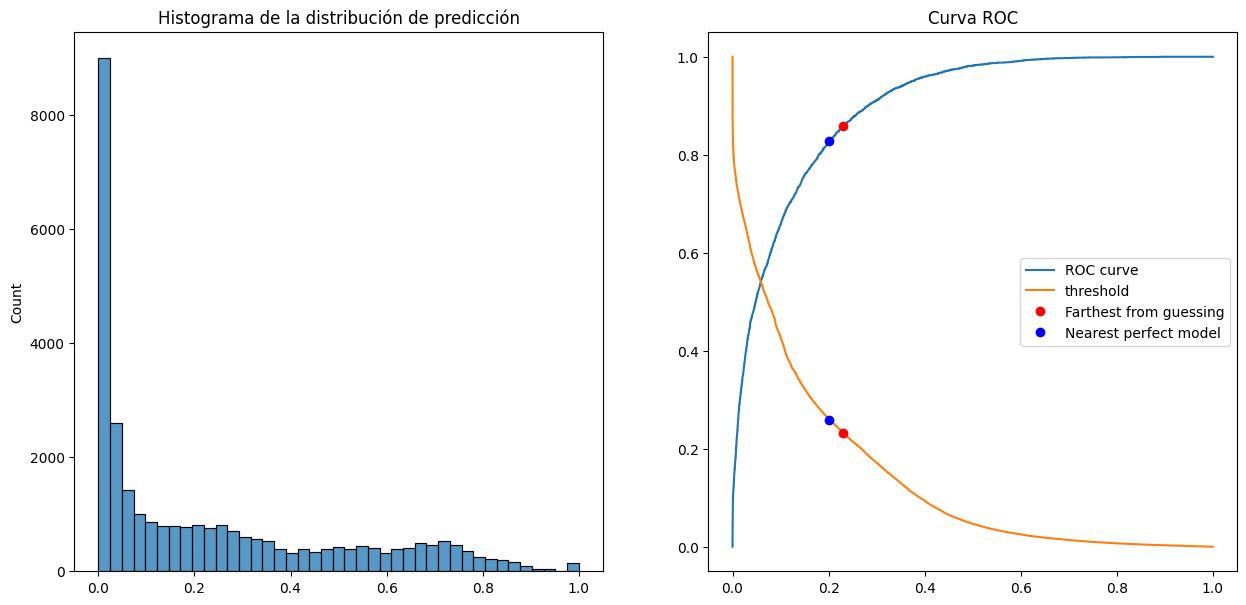

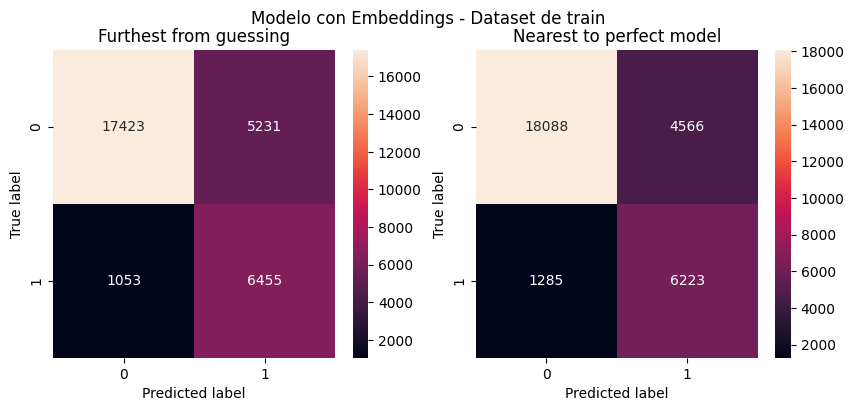

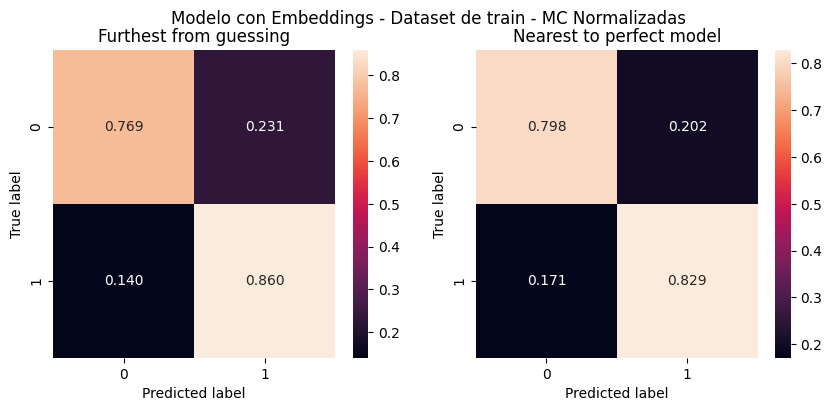

In [ ]:
# Evaluate train dataset as 1
model.eval()
X = torch.tensor(df_encoded.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long).to(device)
occupation = torch.tensor(df_encoded['occupation'].values, dtype=torch.long).to(device)
country = torch.tensor(df_encoded['native-country'].values, dtype=torch.long).to(device)
with torch.no_grad():
    yhat = model(X, occupation, country).cpu().numpy()

thr_J, thr_gd = get_best_thresholds(yhat=yhat, y_true=df_encoded['income'])

fig, axs = plt.subplots(1,2, figsize=(15,7))

# Histograma de la distribución de predicción
sns.histplot(yhat, ax=axs[0])
axs[0].set_title('Histograma de la distribución de predicción')

fpr, tpr, thr = sklearn.metrics.roc_curve(y_true=df_encoded['income'], y_score=yhat)
axs[1].plot(fpr, tpr, label='ROC curve')
axs[1].plot(fpr, thr, label='threshold')
J = tpr - fpr
idx_J = np.argmax(J)
axs[1].plot(fpr[idx_J], tpr[idx_J],'ro', label='Farthest from guessing')
axs[1].plot(fpr[idx_J], thr[idx_J],'ro')

geom_dist = np.sqrt((1-tpr)**2 + fpr**2)
idx_gd = np.argmin(geom_dist)
axs[1].plot(fpr[idx_gd], tpr[idx_gd],'bo', label='Nearest perfect model')
axs[1].plot(fpr[idx_gd], thr[idx_gd],'bo')

axs[1].legend()
axs[1].set_title('Curva ROC')

plt.show()

yhat_J = apply_threshold(thr_J, yhat)
yhat_gd = apply_threshold(thr_gd, yhat)

cm_J = sklearn.metrics.confusion_matrix(y_true=df_encoded['income'], y_pred=yhat_J)
cm_gd = sklearn.metrics.confusion_matrix(y_true=df_encoded['income'], y_pred=yhat_gd)
cm_J_norm = sklearn.metrics.confusion_matrix(y_true=df_encoded['income'], y_pred=yhat_J, normalize='true')
cm_gd_norm = sklearn.metrics.confusion_matrix(y_true=df_encoded['income'], y_pred=yhat_gd, normalize='true')

plot_thr_confusion_matrixes(cm_J, cm_gd, title='Modelo con Embeddings - Dataset de train', fmt='d')
plot_thr_confusion_matrixes(cm_J_norm, cm_gd_norm, title='Modelo con Embeddings - Dataset de train - MC Normalizadas')

In [55]:
metrics_J = print_metrics(cm_J, 'Modelo con embeddings - más alejado de adivinar')
metrics_gd = print_metrics(cm_gd, 'Modelo con embeddings - más cercano al modelo perfecto')

Modelo con embeddings - más alejado de adivinar
   Sensitivity / Recall = 0.860
   Specificity = 0.769
   Accuracy = 0.792
   Balanced Accuracy = 0.814
   Precision = 0.552
   F1 Score = 0.673
Modelo con embeddings - más cercano al modelo perfecto
   Sensitivity / Recall = 0.829
   Specificity = 0.798
   Accuracy = 0.806
   Balanced Accuracy = 0.814
   Precision = 0.577
   F1 Score = 0.680


Observamos que para el set de train:
- **Del histograma** vemos que claramente tomar arbitrariamente 0.5 como probabilidad de corte no va a ser un buen enfoque y va a dar malos resultas.
- **En la curva ROC** vemos graficados los 2 puntos posibles de umbral, y observamos que son bastante similares:
    - Enfoque más alejado del modelo que adivina (modelo J): 0.2320
    - Enfoque más cercano al modelo perfecto (modelo gd, por geometric distance): 0.2585
- **En las matrices de confusión** observamos que el modelo J tiene una mayor tasa de positivos predichos, a costas de predecir peor los negativos y de predecir muchos falsos positivos.
- **En cuanto a métricas**, se ve que el modelo J tiene mejor sensibilidad y peor especificidad. En cuanto a una métrica que balancee ambas como la precisión balanceada, se tiene el mismo valor para ambas, y en el F1 score se tiene un mejor resultado para el modelo gd. Se ve una pobre precisión, algo que se condice con la alta cantidad de falsos positivos.

**Se concluye proceder utilizando el enfoque del modelo más alejado de adivinar, y utilizar un threshold de 0.2320.**

A continuación vamos a evaluar el dataset de testeo:

In [89]:
df_test = pd.read_csv('adult_val.csv')

# Primero agrupo las educaciones como hice con el dataset de train
df_test['education'] = df_test['education'].map(group_eds)

df_test_encoded = scale_test_df(df_test, df, scalers)

sex -> OneHotEncoder(drop='if_binary')
capital-gain -> StandardScaler()
capital-loss -> StandardScaler()
hours-per-week -> StandardScaler()
education -> OrdinalEncoder(categories=[['No-Diploma', 'HS-grad', 'Some-college',
                            'Associate', 'Bachelors', 'Masters', 'Prof-school',
                            'Doctorate']])
workclass -> OneHotEncoder()
marital-status -> OneHotEncoder()
relationship -> OneHotEncoder()
race -> OneHotEncoder()
occupation -> LabelEncoder()
native-country -> LabelEncoder()
income -> OrdinalEncoder(categories=[['<=50K', '>50K']])


In [ ]:
model.eval()
X_test = torch.tensor(df_test_encoded.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long).to(device)
occupation_test = torch.tensor(df_test_encoded['occupation'].values, dtype=torch.long).to(device)
country_test = torch.tensor(df_test_encoded['native-country'].values, dtype=torch.long).to(device)
with torch.no_grad():
    yhat_test = model(X_test, occupation_test, country_test).cpu().numpy()

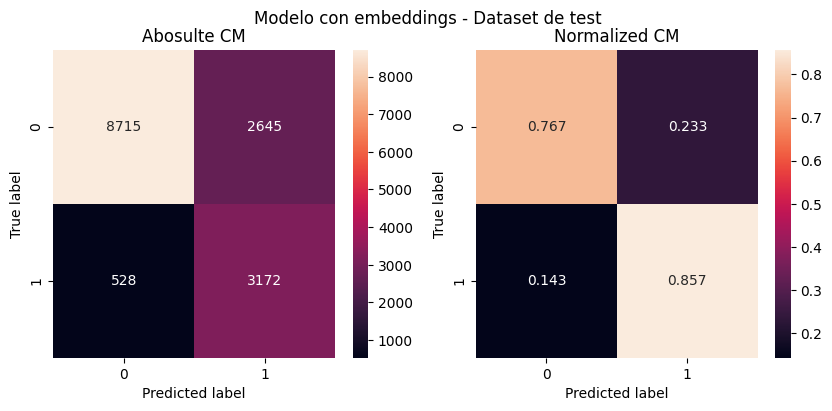

Modelo con embeddings - set de test
   Sensitivity / Recall = 0.857
   Specificity = 0.767
   Accuracy = 0.789
   Balanced Accuracy = 0.812
   Precision = 0.545
   F1 Score = 0.667

SkLearn Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.77      0.85     11360
         1.0       0.55      0.86      0.67      3700

    accuracy                           0.79     15060
   macro avg       0.74      0.81      0.76     15060
weighted avg       0.85      0.79      0.80     15060



In [99]:
yhat_test_thr = apply_threshold(thr_J, yhat_test)

cm_test = sklearn.metrics.confusion_matrix(y_true=df_test_encoded['income'], y_pred=yhat_test_thr)
cm_test_norm = sklearn.metrics.confusion_matrix(y_true=df_test_encoded['income'], y_pred=yhat_test_thr, normalize='true')

plot_confusion_matrix(cm_test, cm_test_norm, title='Modelo con embeddings - Dataset de test')

metrics_test = print_metrics(cm = cm_test, model_name='Modelo con embeddings - set de test')

print('\nSkLearn Classification Report:')
print(sklearn.metrics.classification_report(y_true=df_test_encoded['income'], y_pred=yhat_test_thr))

Observamos que:
- **En la matriz de confusión absoluta** que se predicen casi tantos verdaderos positivos como falsos positivos, al igual que en entrenamiento.
- **En la matriz de confusión normalizada** que no varían las proporciones respecto del entrenamiento, lo cual nos indica que el modelo no esta haciendo sobreajuste.
- **En las métricas** vemos que el modelo retiene buena sensibilidad, aunque una pobre precisión (justamente por predecir tantos falsos positivos).

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, mismas neuronas, mismas funciones de activación y la misma probabilidad de dropout.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

In [57]:
scalers_to_use = {
    'sex': 'one_hot_binary',
    'capital-gain': 'standard',
    'capital-loss': 'standard',
    'hours-per-week': 'standard',
    'education': 'ordinal',
    'workclass': 'one_hot',
    'marital-status': 'one_hot',
    'relationship': 'one_hot',
    'race': 'one_hot',
    'occupation': 'one_hot',
    'native-country': 'one_hot',
    'income': 'ordinal'
}
ordinal_encoder_cats = {
    'education': ['No-Diploma', 'HS-grad', 'Some-college', 'Associate', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate'],
    'income': ['<=50K', '>50K'] 
}
df_encoded_noemb, scalers_noemb, len_labels_noemb = scale_df(df, scalers_to_use, ordinal_encoder_cats)
df_encoded_noemb

,age,sex,capital-gain,capital-loss,hours-per-week,education,State-gov,Self-emp-not-inc,Private,Federal-gov,...,Scotland,Trinadad&Tobago,Greece,Nicaragua,Vietnam,Hong,Ireland,Hungary,Holand-Netherlands,income
0,39,1.0,0.146092,-0.218586,-0.077734,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,50,1.0,-0.147445,-0.218586,-2.331531,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,38,1.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,53,1.0,-0.147445,-0.218586,-0.077734,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,28,0.0,-0.147445,-0.218586,-0.077734,4.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,0.0,-0.147445,-0.218586,-0.244682,3.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30158,40,1.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
30159,58,0.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30160,22,1.0,-0.147445,-0.218586,-1.747213,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [71]:
from torch.utils.data import DataLoader, Dataset
from torch import nn
from collections import OrderedDict

class NNetModel_noEmb(nn.Module):
    def __init__(self, x_shape, n_per_layer=128, layers=4,p=0.1):
        super().__init__()
        # definamos la red
        # capa de input
        network_order = [
            ('input_drop', nn.Dropout(p)),
            ('input', nn.Linear(x_shape - 1, n_per_layer)),
            ('input_act', nn.LeakyReLU())
        ]
        # capas ocultas
        for i in range(layers):
            network_order.append((f'drop_{i}', nn.Dropout(p)))
            network_order.append((f'layer_{i}', nn.Linear(n_per_layer, n_per_layer)))
            network_order.append((f'act_{i}', nn.LeakyReLU()))
        # capas de output
        network_order.append((f'drop_out', nn.Dropout(p)))
        network_order.append((f'output', nn.Linear(n_per_layer, 1)))
        network_order.append((f'out_act', nn.Sigmoid()))
        # instanciemos la red
        self.network = nn.Sequential(
            OrderedDict(network_order) 
        )
    
    def forward(self, x):
        y = self.network(x)
        return y.squeeze(1)

def train_model_noemb(model, dataloader, optimizer, criteria, epochs=100, log=True):
    loss_evol = []

    for epoch in range(epochs):
        model.train()
        train_mse = []
        for xi, yi in dataloader:
            yhat = model(xi)
            loss = criteria(yhat, yi.flatten())
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            train_mse.append(loss.item())
        loss_evol.append(np.mean(train_mse))
        if log:
            print(f'Epoch {epoch+1}: loss={np.mean(train_mse)}')
    
    return loss_evol


In [ ]:
from torch.utils.data import TensorDataset

X_noemb = torch.tensor(df_encoded_noemb.drop('income', axis=1).values, dtype=torch.float32).to(device)
y_noemb = torch.tensor(df_encoded_noemb[['income']].values, dtype=torch.float32).to(device)
x_shape_noemb = df_encoded_noemb.shape[1]

dataset_noemb = TensorDataset(X_noemb, y_noemb)
dataloader_noemb = DataLoader(dataset_noemb, batch_size=1024, shuffle=True)
model_noemb = NNetModel_noEmb(x_shape=x_shape_noemb, layers=layers, n_per_layer=n_per_layer).to(device)
criteria_noemb = nn.BCELoss()
optimizer_noemb = torch.optim.Adam(model_noemb.parameters(), lr=5e-4)
    

In [ ]:
# Train time:
train_times_noemb = []
for i in range(10):
    start_time = time.perf_counter()
    _ = train_model_noemb(model_noemb, dataloader_noemb, optimizer_noemb, criteria_noemb, epochs=100, log=False)
    end_time = time.perf_counter()
    print(f"Elapsed time training = {(end_time - start_time):.2f}s")
    train_times_noemb.append(end_time - start_time)

train_time_noemb = np.mean(train_times_noemb)

# Test time:
test_times_noemb = []
for i in range(10):
    start_time = time.perf_counter()
    model_noemb.eval()
    X_noemb = torch.tensor(df_encoded_noemb.drop('income', axis=1).values, dtype=torch.float32).to(device)
    with torch.no_grad():
        yhat_noemb = model_noemb(X_noemb).cpu().numpy()
    end_time = time.perf_counter()
    print(f"Elapsed time predicting = {(end_time - start_time):.2f}s")
    test_times_noemb.append(end_time - start_time)

test_time_noemb = np.mean(test_times_noemb)

Elapsed time training = 43.42s
Elapsed time training = 39.89s
Elapsed time training = 48.42s
Elapsed time training = 48.05s
Elapsed time training = 45.92s
Elapsed time training = 44.34s
Elapsed time training = 44.28s
Elapsed time training = 45.90s
Elapsed time training = 39.61s
Elapsed time training = 42.55s
Elapsed time predicting = 0.10s
Elapsed time predicting = 0.02s
Elapsed time predicting = 0.02s
Elapsed time predicting = 0.02s
Elapsed time predicting = 0.01s
Elapsed time predicting = 0.06s
Elapsed time predicting = 0.10s
Elapsed time predicting = 0.03s
Elapsed time predicting = 0.05s
Elapsed time predicting = 0.03s


In [ ]:
epochs = 100
loss_evol_noemb = train_model_noemb(model_noemb, dataloader_noemb, optimizer_noemb, criteria_noemb, epochs)

Epoch 1: loss=0.6517399807771047
Epoch 2: loss=0.5926779468854269
Epoch 3: loss=0.5713475565115611
Epoch 4: loss=0.5090915590524674
Epoch 5: loss=0.4329321225484212
Epoch 6: loss=0.40859310428301493
Epoch 7: loss=0.39142383833726246
Epoch 8: loss=0.37913478414217633
Epoch 9: loss=0.37036665380001066
Epoch 10: loss=0.3667217920223872
Epoch 11: loss=0.35884070495764414
Epoch 12: loss=0.35889514088630675
Epoch 13: loss=0.35514468550682066
Epoch 14: loss=0.3537811060746511
Epoch 15: loss=0.3529954512914022
Epoch 16: loss=0.35075639486312865
Epoch 17: loss=0.35059582193692523
Epoch 18: loss=0.34845247169335686
Epoch 19: loss=0.3450503617525101
Epoch 20: loss=0.34605694909890494
Epoch 21: loss=0.34515900909900665
Epoch 22: loss=0.3468242834011714
Epoch 23: loss=0.34606443444887797
Epoch 24: loss=0.34197699328263603
Epoch 25: loss=0.34628307024637855
Epoch 26: loss=0.3425592243671417
Epoch 27: loss=0.3425035874048869
Epoch 28: loss=0.3403575678666433
Epoch 29: loss=0.34374845822652184
Epoch 3

NameError: name 'loss_evol_no_emb' is not defined

Text(0.5, 1.0, 'Pérdida en entrenamiento para modelo sin embbedings')

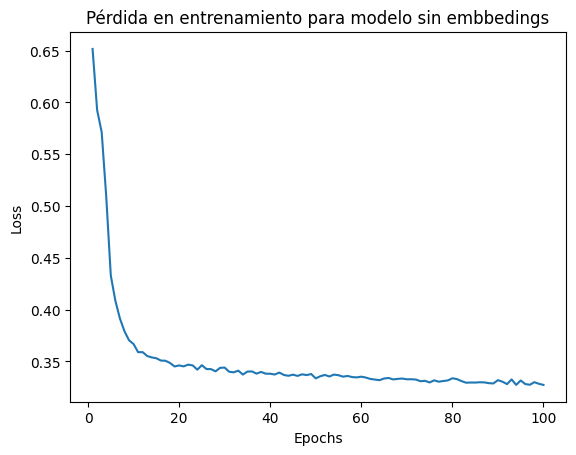

In [75]:
plt.plot(range(1,epochs+1), loss_evol_noemb)
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.title('Pérdida en entrenamiento para modelo sin embbedings')

Threshold for farthest from guessing model: 0.2301


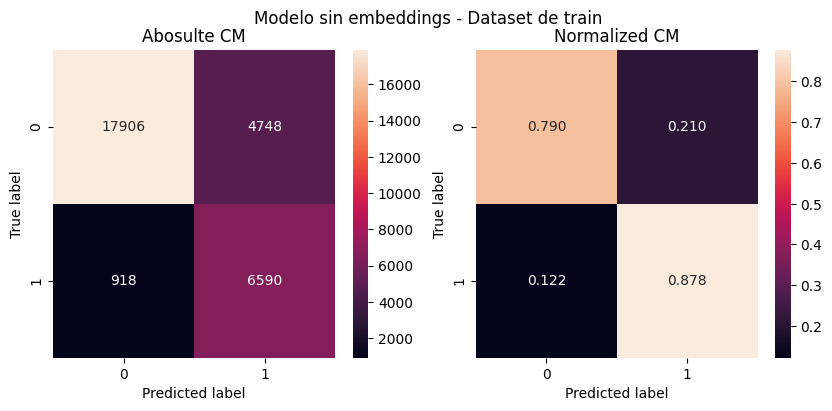

Modelo sin embeddings
   Sensitivity / Recall = 0.878
   Specificity = 0.790
   Accuracy = 0.812
   Balanced Accuracy = 0.834
   Precision = 0.581
   F1 Score = 0.699


In [ ]:
model_noemb.eval()
X_noemb = torch.tensor(df_encoded_noemb.drop('income', axis=1).values, dtype=torch.float32).to(device)
with torch.no_grad():
    yhat_noemb = model_noemb(X_noemb).cpu().numpy()

thr_J_noemb, thr_gd_noemb = get_best_thresholds(yhat_noemb, df_encoded_noemb['income'], log=False)
print(f'Threshold for farthest from guessing model: {thr_J_noemb:.4f}')

yhat_noemb_thr = apply_threshold(thr_J_noemb, yhat_noemb)

cm_noemb = sklearn.metrics.confusion_matrix(y_true=df_encoded_noemb['income'], y_pred=yhat_noemb_thr)
cm_noemb_norm = sklearn.metrics.confusion_matrix(y_true=df_encoded_noemb['income'], y_pred=yhat_noemb_thr, normalize='true')

plot_confusion_matrix(cm_noemb, cm_noemb_norm, title='Modelo sin embeddings - Dataset de train')

metrics_noemb = print_metrics(cm_noemb, 'Modelo sin embeddings')

In [95]:
df_test_encoded_noemb = scale_test_df(df_test, df, scalers_noemb)

sex -> OneHotEncoder(drop='if_binary')
capital-gain -> StandardScaler()
capital-loss -> StandardScaler()
hours-per-week -> StandardScaler()
education -> OrdinalEncoder(categories=[['No-Diploma', 'HS-grad', 'Some-college',
                            'Associate', 'Bachelors', 'Masters', 'Prof-school',
                            'Doctorate']])
workclass -> OneHotEncoder()
marital-status -> OneHotEncoder()
relationship -> OneHotEncoder()
race -> OneHotEncoder()
occupation -> OneHotEncoder()
native-country -> OneHotEncoder()
income -> OrdinalEncoder(categories=[['<=50K', '>50K']])


In [3]:
model_noemb.eval()
X_test = torch.tensor(df_test_encoded_noemb.drop('income', axis=1).values, dtype=torch.float32).to(device)
with torch.no_grad():
    yhat_test_noemb = model_noemb(X_test).cpu().numpy()

NameError: name 'model_noemb' is not defined

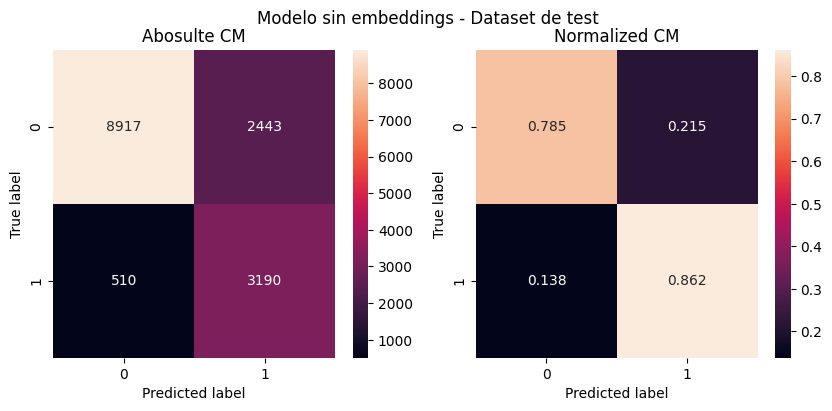

Modelo sin embeddings - set de test
   Sensitivity / Recall = 0.862
   Specificity = 0.785
   Accuracy = 0.804
   Balanced Accuracy = 0.824
   Precision = 0.566
   F1 Score = 0.684

SkLearn Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.78      0.86     11360
         1.0       0.57      0.86      0.68      3700

    accuracy                           0.80     15060
   macro avg       0.76      0.82      0.77     15060
weighted avg       0.85      0.80      0.82     15060



In [100]:
yhat_test_thr_noemb = apply_threshold(thr_J_noemb, yhat_test_noemb)

cm_test_noemb = sklearn.metrics.confusion_matrix(y_true=df_test_encoded_noemb['income'], y_pred=yhat_test_thr_noemb)
cm_test_noemb_norm = sklearn.metrics.confusion_matrix(y_true=df_test_encoded_noemb['income'], y_pred=yhat_test_thr_noemb, normalize='true')

plot_confusion_matrix(cm_test_noemb, cm_test_noemb_norm, title='Modelo sin embeddings - Dataset de test')

metrics_test_noemb = print_metrics(cm = cm_test_noemb, model_name='Modelo sin embeddings - set de test')

print('\nSkLearn Classification Report:')
print(sklearn.metrics.classification_report(y_true=df_test_encoded['income'], y_pred=yhat_test_thr_noemb))


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos.
- Redactar sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.

In [121]:
compiled_metrics = pd.DataFrame({
    'Con embeddings (train)': metrics_J,
    'Con embeddings (test)': metrics_test,
    'Sin embeddings (train)': metrics_noemb,
    'Sin embeddings (test)': metrics_test_noemb,
})
compiled_metrics.index.name = 'Métrica'
compiled_metrics

,Con embeddings (train),Con embeddings (test),Sin embeddings (train),Sin embeddings (test)
Métrica,,,,
sensitivity,0.859750,0.857297,0.877730,0.862162
specificity,0.769092,0.767165,0.790412,0.784947
accuracy,0.791658,0.789309,0.812148,0.803918
balanced_accuracy,0.814421,0.812231,0.834071,0.823555
precision,0.552370,0.545298,0.581231,0.566306
f1,0.552370,0.545298,0.581231,0.566306


In [120]:
compiled_times = pd.DataFrame({
    'Con embeddings (train)': {'tiempo medio [s]' : train_time},
    'Con embeddings (test)': {'tiempo medio [s]' : test_time},
    'Sin embeddings (train)': {'tiempo medio [s]' : train_time_noemb},
    'Sin embeddings (test)': {'tiempo medio [s]' : test_time_noemb},
})
compiled_times

,Con embeddings (train),Con embeddings (test),Sin embeddings (train),Sin embeddings (test)
tiempo medio [s],56.649138,0.019969,44.237358,0.043773


En la tabla comparativa de métricas podemos observar que el modelo con embeddings presenta una sensibilidad (métrica prioritaria según nuestra hipótesis) 2% inferior a la del modelo sin embeddings para entrenamiento, pero igual para evaluación. Ambos modelos tienen pobre precisión y valores similares de F1 score. El modelo sin embeddings presenta métricas levemente superiores, aunque ambos modelos tienen los mismos problemas, inherente a que su estructura es igual.

Creo que debido a que se daba cardinalidad muy alta sólo en 1 de las features y que quizas esta feature no era tan importante para la predicción del nivel de ingreso comparativamente a otras features, el aplicar embeddings no presentó suficiente mejora al modelo frente a usar one-hot encoding de forma directa para las features de alta cardinalidad.

Podemos ver también el análisis del costo computacional, con un mayor tiempo de entrenamiento para el modelo con embeddings, mientras que un menor tiempo predicción. Esto último podría hacer que sea más atractivo al aplicarse a producción, donde se está constantemente haciendo predicciones, y tener la mitad de tiempo de predicción podría ser beneficioso. Esta mejora en tiempo de predicción seguramente venga de la mano de que se utilizó una dimensión chica para los embeddings, por lo que la cantidad de cuentas a realizar se achico considerablemente, especialmente para la feature de país de origen.

**Se concluye que en este caso no se obtiene una mejora importante al aplicar ebeddings más allá de una reducción en el tiempo de predicción, a pesar de la alta cardinalidad de 2 de las features del modelo.**